In [60]:
import pandas as pd
import numpy as np

df = pd.read_csv('Automobile_data.csv')
print('Original shape:',df.shape)
df.head()

Original shape: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [61]:
df.describe(include='all')

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205,205,205.000000,205,205,205.000000,205.000000,205
unique,NaN,52,22,2,2,3,5,3,2,NaN,...,NaN,8,39,37,NaN,60,24,NaN,NaN,187
top,NaN,?,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,3.62,3.4,NaN,68,5500,NaN,NaN,?
freq,NaN,41,32,185,168,114,96,120,202,NaN,...,NaN,94,23,20,NaN,19,37,NaN,NaN,4
mean,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,NaN,NaN,10.142537,NaN,NaN,25.219512,30.751220,NaN
std,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,NaN,NaN,3.972040,NaN,NaN,6.542142,6.886443,NaN
min,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,NaN,NaN,7.000000,NaN,NaN,13.000000,16.000000,NaN
25%,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,NaN,NaN,8.600000,NaN,NaN,19.000000,25.000000,NaN
50%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,NaN,NaN,9.000000,NaN,NaN,24.000000,30.000000,NaN
75%,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,NaN,NaN,9.400000,NaN,NaN,30.000000,34.000000,NaN


In [62]:
df.replace('?', np.nan, inplace=True)

for col in ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']:
    df[col] = pd.to_numeric(df[col])

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print('Missing values after ? → NaN conversion:')
missing_summary[missing_summary['Missing'] > 0]

Missing values after ? → NaN conversion:


,Missing,Percent
normalized-losses,41,20.0
num-of-doors,2,1.0
bore,4,2.0
stroke,4,2.0
horsepower,2,1.0
peak-rpm,2,1.0
price,4,2.0


In [63]:
# --- Handle missing values ---

# 1. Drop rows where price is missing (it's our target variable)
df.dropna(subset=['price'], inplace=True)

# 2. Fill num-of-doors with mode (most common = 'four')
df['num-of-doors'].fillna(df['num-of-doors'].mode()[0], inplace=True)

# 3. Fill remaining numeric columns with their median
median_fill_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in median_fill_cols:
    df[col].fillna(df[col].median(), inplace=True)

# --- Verify no missing values remain ---
print(f'Shape after cleaning: {df.shape}')
print(f'Remaining nulls: {df.isnull().sum().sum()}')
print(f'\nAll dtypes now correct:')
df.dtypes

Shape after cleaning: (201, 26)
Remaining nulls: 51

All dtypes now correct:


C:\Users\adity.ROYALIDEAPADPRO\AppData\Local\Temp\ipykernel_13408\2024982314.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['num-of-doors'].fillna(df['num-of-doors'].mode()[0], inplace=True)
C:\Users\adity.ROYALIDEAPADPRO\AppData\Local\Temp\ipykernel_13408\2024982314.py:12: ChainedAssignmentError: A value is being set on a co

symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

## 🏷️ Step 2: Encoding Categorical Variables
- **Label Encoding** for ordinal / binary categories (fuel-type, aspiration, etc.)
- **One-Hot Encoding** for nominal categories with multiple values (make, body-style, etc.)

In [64]:
from sklearn.preprocessing import LabelEncoder

# --- Label Encoding for binary / low-cardinality ordinal columns ---
label_encode_cols = ['fuel-type', 'aspiration', 'engine-location']

le = LabelEncoder()
label_mappings = {}
for col in label_encode_cols:
    df[col] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('Label Encoding Mappings:')
for col, mapping in label_mappings.items():
    print(f'  {col}: {mapping}')

Label Encoding Mappings:
  fuel-type: {'diesel': np.int64(0), 'gas': np.int64(1)}
  aspiration: {'std': np.int64(0), 'turbo': np.int64(1)}
  engine-location: {'front': np.int64(0), 'rear': np.int64(1)}


In [65]:
# --- Map num-of-cylinders from word to number ---
cylinder_map = {
    'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'eight': 8, 'twelve': 12
}
df['num-of-cylinders'] = df['num-of-cylinders'].map(cylinder_map)

# --- Map num-of-doors from word to number ---
door_map = {'two': 2, 'four': 4}
df['num-of-doors'] = df['num-of-doors'].map(door_map)

print('Cylinders unique values:', sorted(df['num-of-cylinders'].unique()))
print('Doors unique values:', sorted(df['num-of-doors'].unique()))

Cylinders unique values: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(12)]
Doors unique values: [np.float64(2.0), np.float64(4.0), np.float64(nan)]


In [66]:
# --- One-Hot Encoding for nominal multi-class columns ---
onehot_cols = ['body-style', 'drive-wheels', 'engine-type', 'fuel-system']

df_encoded = pd.get_dummies(df, columns=onehot_cols, drop_first=True, dtype=int)

print(f'Shape after one-hot encoding: {df_encoded.shape}')
print(f'\nNew columns added ({df_encoded.shape[1] - df.shape[1] + len(onehot_cols)}):')
new_cols = [c for c in df_encoded.columns if any(c.startswith(p + '_') for p in onehot_cols)]
print(new_cols)

Shape after one-hot encoding: (201, 40)

New columns added (18):
['body-style_hardtop', 'body-style_hatchback', 'body-style_sedan', 'body-style_wagon', 'drive-wheels_fwd', 'drive-wheels_rwd', 'engine-type_l', 'engine-type_ohc', 'engine-type_ohcf', 'engine-type_ohcv', 'engine-type_rotor', 'fuel-system_2bbl', 'fuel-system_4bbl', 'fuel-system_idi', 'fuel-system_mfi', 'fuel-system_mpfi', 'fuel-system_spdi', 'fuel-system_spfi']


In [67]:
# --- Revert label encoding so df stays human-readable ---
df['fuel-type'] = df['fuel-type'].map({0: 'diesel', 1: 'gas'})
df['aspiration'] = df['aspiration'].map({0: 'std', 1: 'turbo'})
df['engine-location'] = df['engine-location'].map({0: 'front', 1: 'rear'})

# --- Rename columns for better readability ---
df.rename(columns={
    'symboling':          'Risk Rating',
    'normalized-losses':  'Insurance Risk Score',
    'make':               'Company',
    'fuel-type':          'Fuel Type',
    'aspiration':         'Aspiration',
    'num-of-doors':       'Doors',
    'body-style':         'Body Style',
    'drive-wheels':       'Drive Wheels',
    'engine-location':    'Engine Location',
    'wheel-base':         'Wheelbase',
    'length':             'Length',
    'width':              'Width',
    'height':             'Height',
    'curb-weight':        'Curb Weight',
    'engine-type':        'Engine Type',
    'num-of-cylinders':   'Cylinders',
    'engine-size':        'Engine Size',
    'fuel-system':        'Fuel System',
    'bore':               'Bore',
    'stroke':             'Stroke',
    'compression-ratio':  'Compression Ratio',
    'horsepower':         'Horsepower',
    'peak-rpm':           'Peak RPM',
    'city-mpg':           'City MPG',
    'highway-mpg':        'Highway MPG',
    'price':              'Price'
}, inplace=True)

print('Renamed columns:')
print(df.columns.tolist())
df.head()

Renamed columns:
['Risk Rating', 'Insurance Risk Score', 'Company', 'Fuel Type', 'Aspiration', 'Doors', 'Body Style', 'Drive Wheels', 'Engine Location', 'Wheelbase', 'Length', 'Width', 'Height', 'Curb Weight', 'Engine Type', 'Cylinders', 'Engine Size', 'Fuel System', 'Bore', 'Stroke', 'Compression Ratio', 'Horsepower', 'Peak RPM', 'City MPG', 'Highway MPG', 'Price']


,Risk Rating,Insurance Risk Score,Company,Fuel Type,Aspiration,Doors,Body Style,Drive Wheels,Engine Location,Wheelbase,...,Engine Size,Fuel System,Bore,Stroke,Compression Ratio,Horsepower,Peak RPM,City MPG,Highway MPG,Price
0,3,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,2.0,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,4.0,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,4.0,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


## 📊 Step 3: Basic Visualizations & Frequency Tables

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

In [69]:
# --- Frequency Tables for key categorical columns ---
cat_cols = ['Company', 'Body Style', 'Fuel Type', 'Aspiration', 'Drive Wheels',
            'Engine Type', 'Doors', 'Cylinders']

for col in cat_cols:
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    table = pd.DataFrame({'Count': freq, 'Percent': pct})
    print(f'\n{"=" * 40}')
    print(f'  {col.upper()}')
    print(f'{"=" * 40}')
    print(table.to_string())



  COMPANY
               Count  Percent
Company                      
toyota            32     15.9
nissan            18      9.0
mazda             17      8.5
honda             13      6.5
mitsubishi        13      6.5
subaru            12      6.0
volkswagen        12      6.0
peugot            11      5.5
volvo             11      5.5
dodge              9      4.5
bmw                8      4.0
mercedes-benz      8      4.0
plymouth           7      3.5
audi               6      3.0
saab               6      3.0
porsche            4      2.0
alfa-romero        3      1.5
chevrolet          3      1.5
jaguar             3      1.5
isuzu              2      1.0
renault            2      1.0
mercury            1      0.5

  BODY STYLE
             Count  Percent
Body Style                 
sedan           94     46.8
hatchback       68     33.8
wagon           25     12.4
hardtop          8      4.0
convertible      6      3.0

  FUEL TYPE
           Count  Percent
Fuel Type           

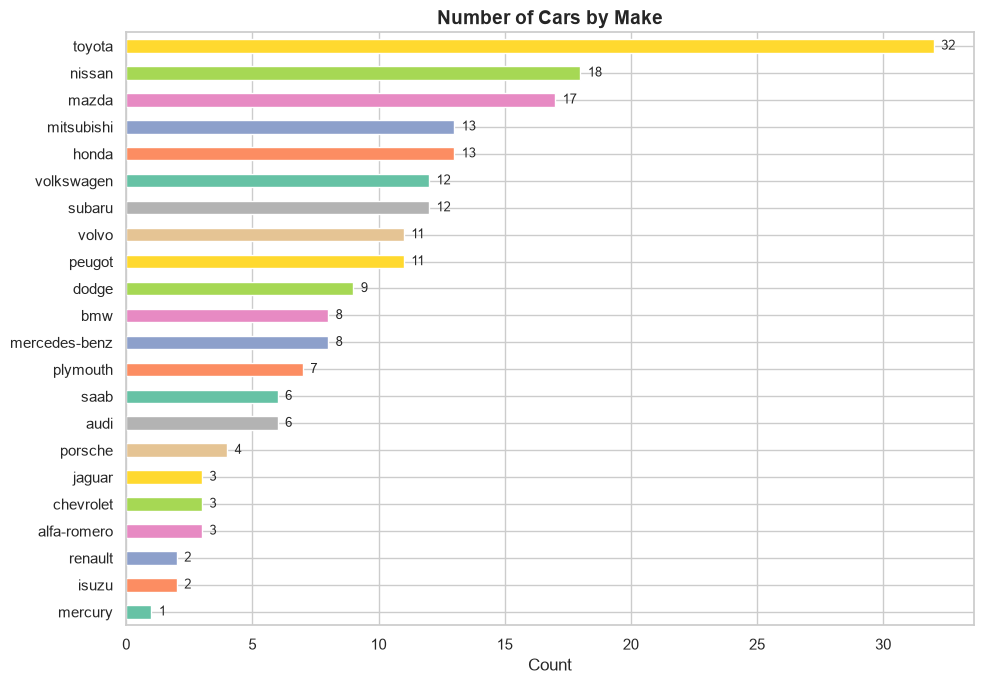

In [70]:
# --- Car count by Make (horizontal bar) ---
fig, ax = plt.subplots(figsize=(10, 7))
df['Company'].value_counts().sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('Set2', 22))
ax.set_title('Number of Cars by Make', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('')
for i, v in enumerate(df['Company'].value_counts().sort_values()):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

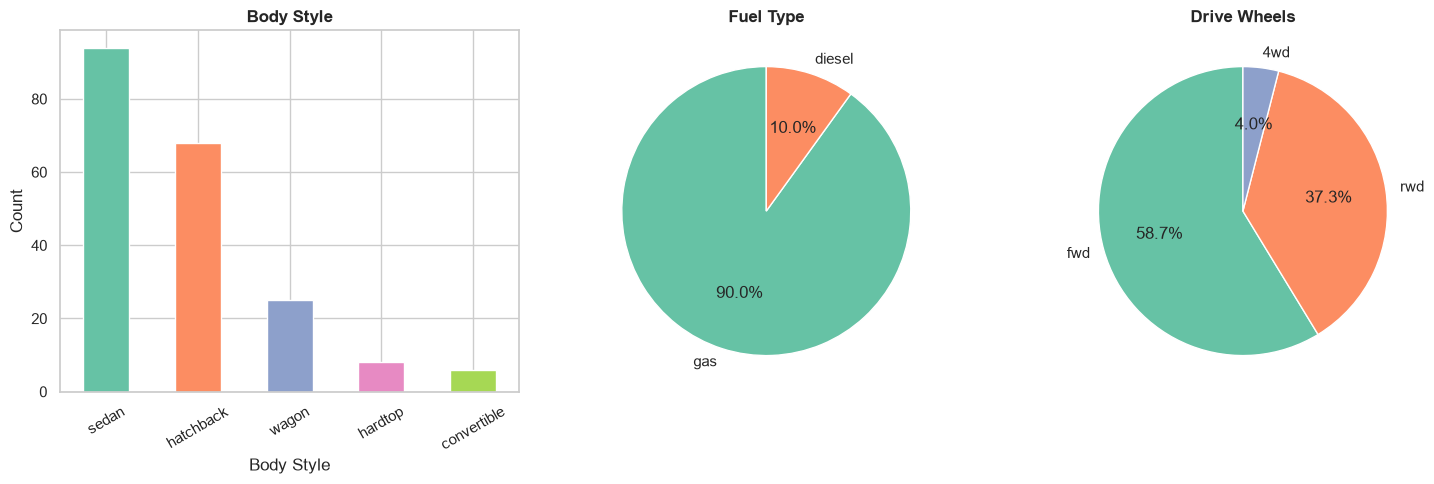

In [71]:
# --- Body Style & Fuel Type distributions ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Body Style
df['Body Style'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Body Style', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Fuel Type
df['Fuel Type'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Fuel Type', fontweight='bold')
axes[1].set_ylabel('')

# Drive Wheels
df['Drive Wheels'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%',
    colors=sns.color_palette('Set2'), startangle=90)
axes[2].set_title('Drive Wheels', fontweight='bold')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

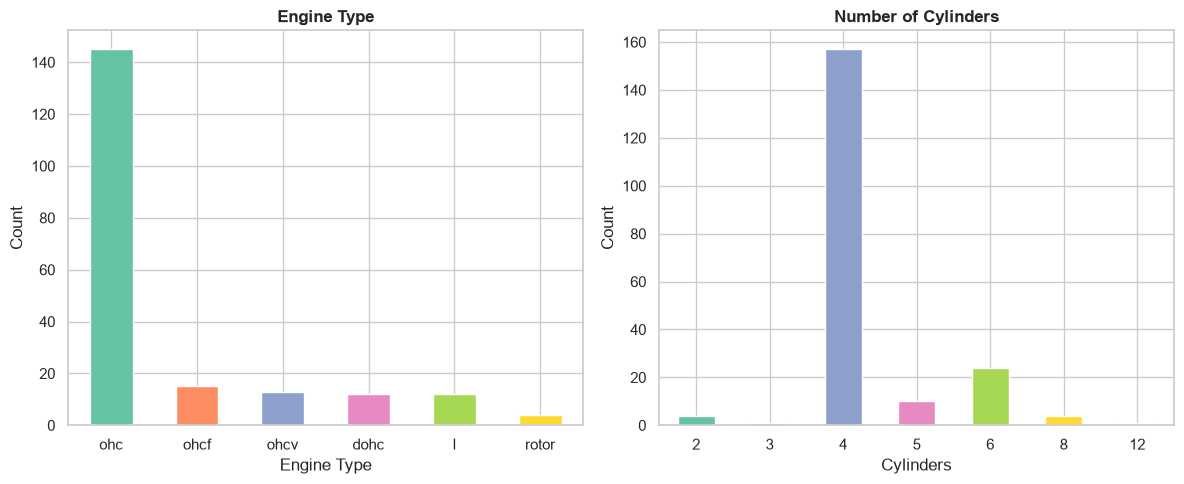

In [72]:
# --- Engine Type & Cylinders distributions ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Engine Type'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Engine Type', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Cylinders'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Number of Cylinders', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

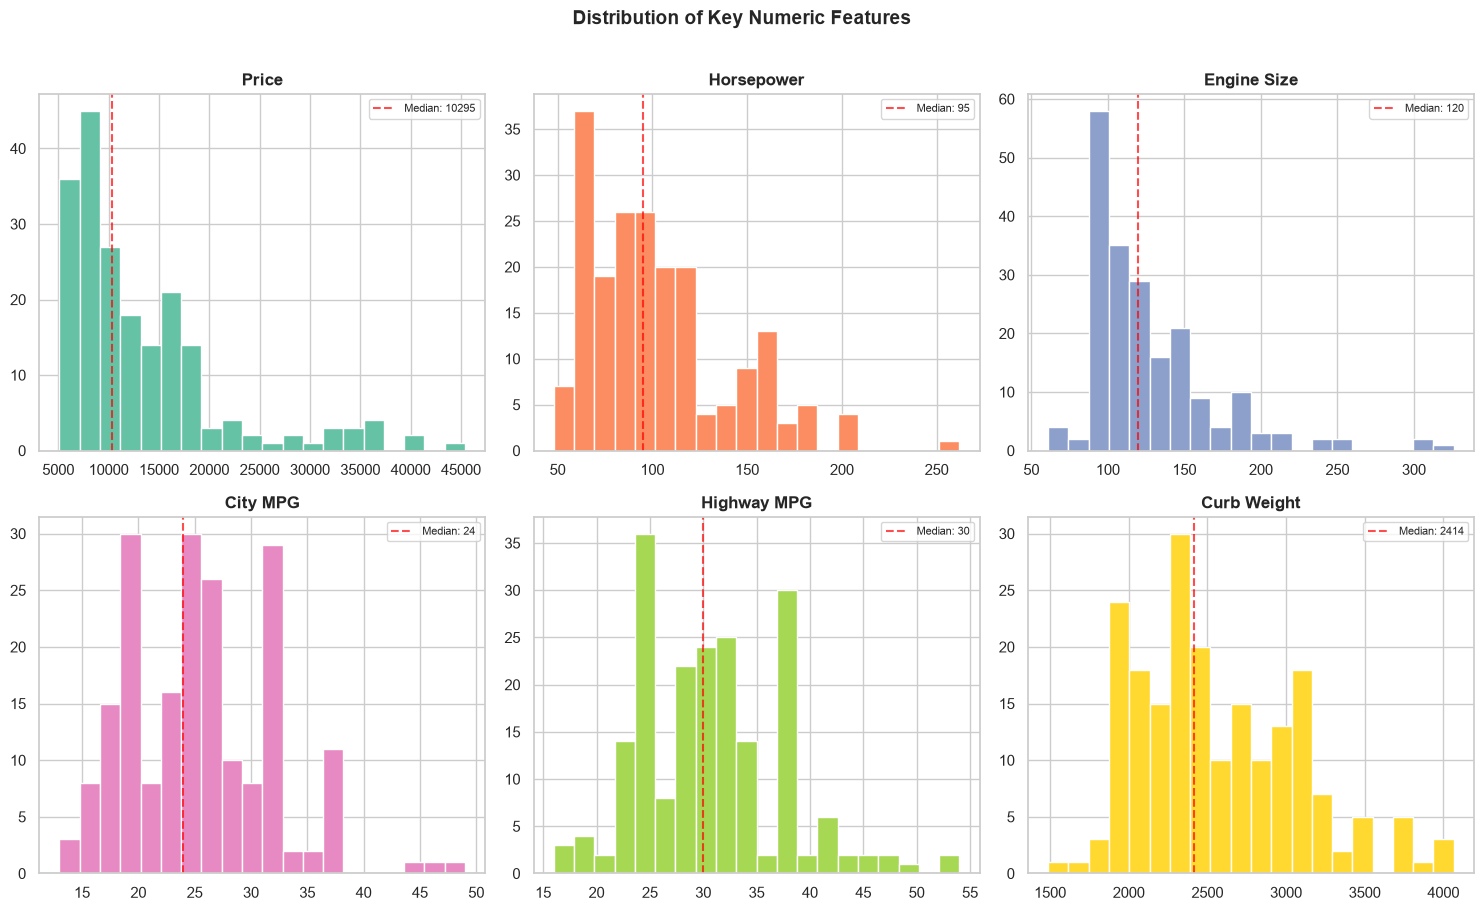

In [73]:
# --- Histograms for key numeric columns ---
num_cols = ['Price', 'Horsepower', 'Engine Size', 'City MPG', 'Highway MPG', 'Curb Weight']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color=sns.color_palette('Set2')[i], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].axvline(df[col].median(), color='red', linestyle='--', alpha=0.7, label=f'Median: {df[col].median():.0f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Key Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [74]:
# --- Cross-tabulation: Body Style vs Fuel Type ---
print('Body Style vs Fuel Type (crosstab):')
ct = pd.crosstab(df['Body Style'], df['Fuel Type'], margins=True)
print(ct)

print('\n\nBody Style vs Drive Wheels (crosstab):')
ct2 = pd.crosstab(df['Body Style'], df['Drive Wheels'], margins=True)
print(ct2)

Body Style vs Fuel Type (crosstab):
Fuel Type    diesel  gas  All
Body Style                   
convertible       0    6    6
hardtop           1    7    8
hatchback         1   67   68
sedan            15   79   94
wagon             3   22   25
All              20  181  201


Body Style vs Drive Wheels (crosstab):
Drive Wheels  4wd  fwd  rwd  All
Body Style                      
convertible     0    1    5    6
hardtop         0    1    7    8
hatchback       1   49   18   68
sedan           3   55   36   94
wagon           4   12    9   25
All             8  118   75  201


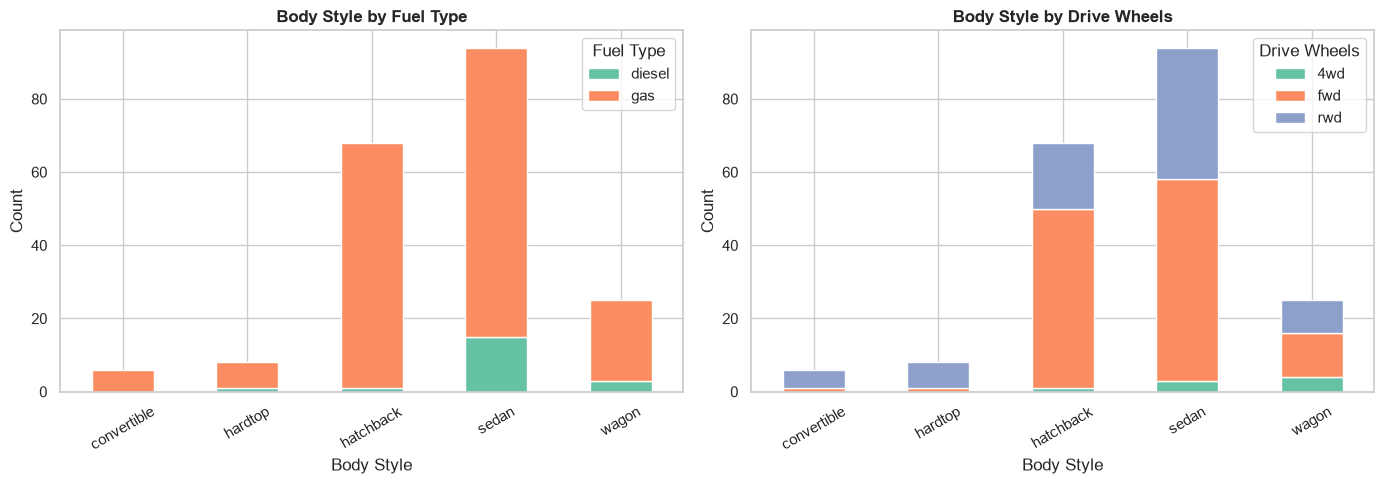

In [75]:
# --- Stacked bar: Body Style by Fuel Type ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.crosstab(df['Body Style'], df['Fuel Type']).plot(
    kind='bar', stacked=True, ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Body Style by Fuel Type', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Fuel Type')

pd.crosstab(df['Body Style'], df['Drive Wheels']).plot(
    kind='bar', stacked=True, ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Body Style by Drive Wheels', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Drive Wheels')

plt.tight_layout()
plt.show()

## 📈 KDE vs Normal Curve — Near-Normal Features
These features have the lowest skewness and highest Shapiro-Wilk p-values, meaning they most closely resemble a normal (bell curve) distribution.

In [76]:
from scipy import stats

def kde_vs_normal(data, col_name, ax):
    """Overlay KDE of actual data against a fitted normal curve with Shapiro-Wilk test."""
    clean = data.dropna()
    mu, sigma = clean.mean(), clean.std()

    # Histogram (light background)
    ax.hist(clean, bins=20, density=True, alpha=0.25, color='#3498db', edgecolor='white')

    # KDE — actual distribution
    sns.kdeplot(clean, ax=ax, color='#e74c3c', linewidth=2.5, label='KDE (Actual)')

    # Fitted normal curve
    x = np.linspace(clean.min() - sigma, clean.max() + sigma, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color='#2c3e50', linewidth=2,
            linestyle='--', label=f'Normal (\u03bc={mu:.1f}, \u03c3={sigma:.1f})')

    # Fill area between KDE and Normal to highlight deviation
    kde = stats.gaussian_kde(clean)
    kde_vals = kde(x)
    norm_vals = stats.norm.pdf(x, mu, sigma)
    ax.fill_between(x, kde_vals, norm_vals, alpha=0.15, color='orange', label='Deviation')

    # Shapiro-Wilk normality test
    stat_val, p = stats.shapiro(clean[:min(len(clean), 150)])
    skew = clean.skew()
    kurt = clean.kurtosis()

    ax.set_title(f'{col_name}\nSkew={skew:.2f}  Kurt={kurt:.2f}  Shapiro p={p:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, loc='upper right')

print('kde_vs_normal() defined \u2713')

kde_vs_normal() defined ✓


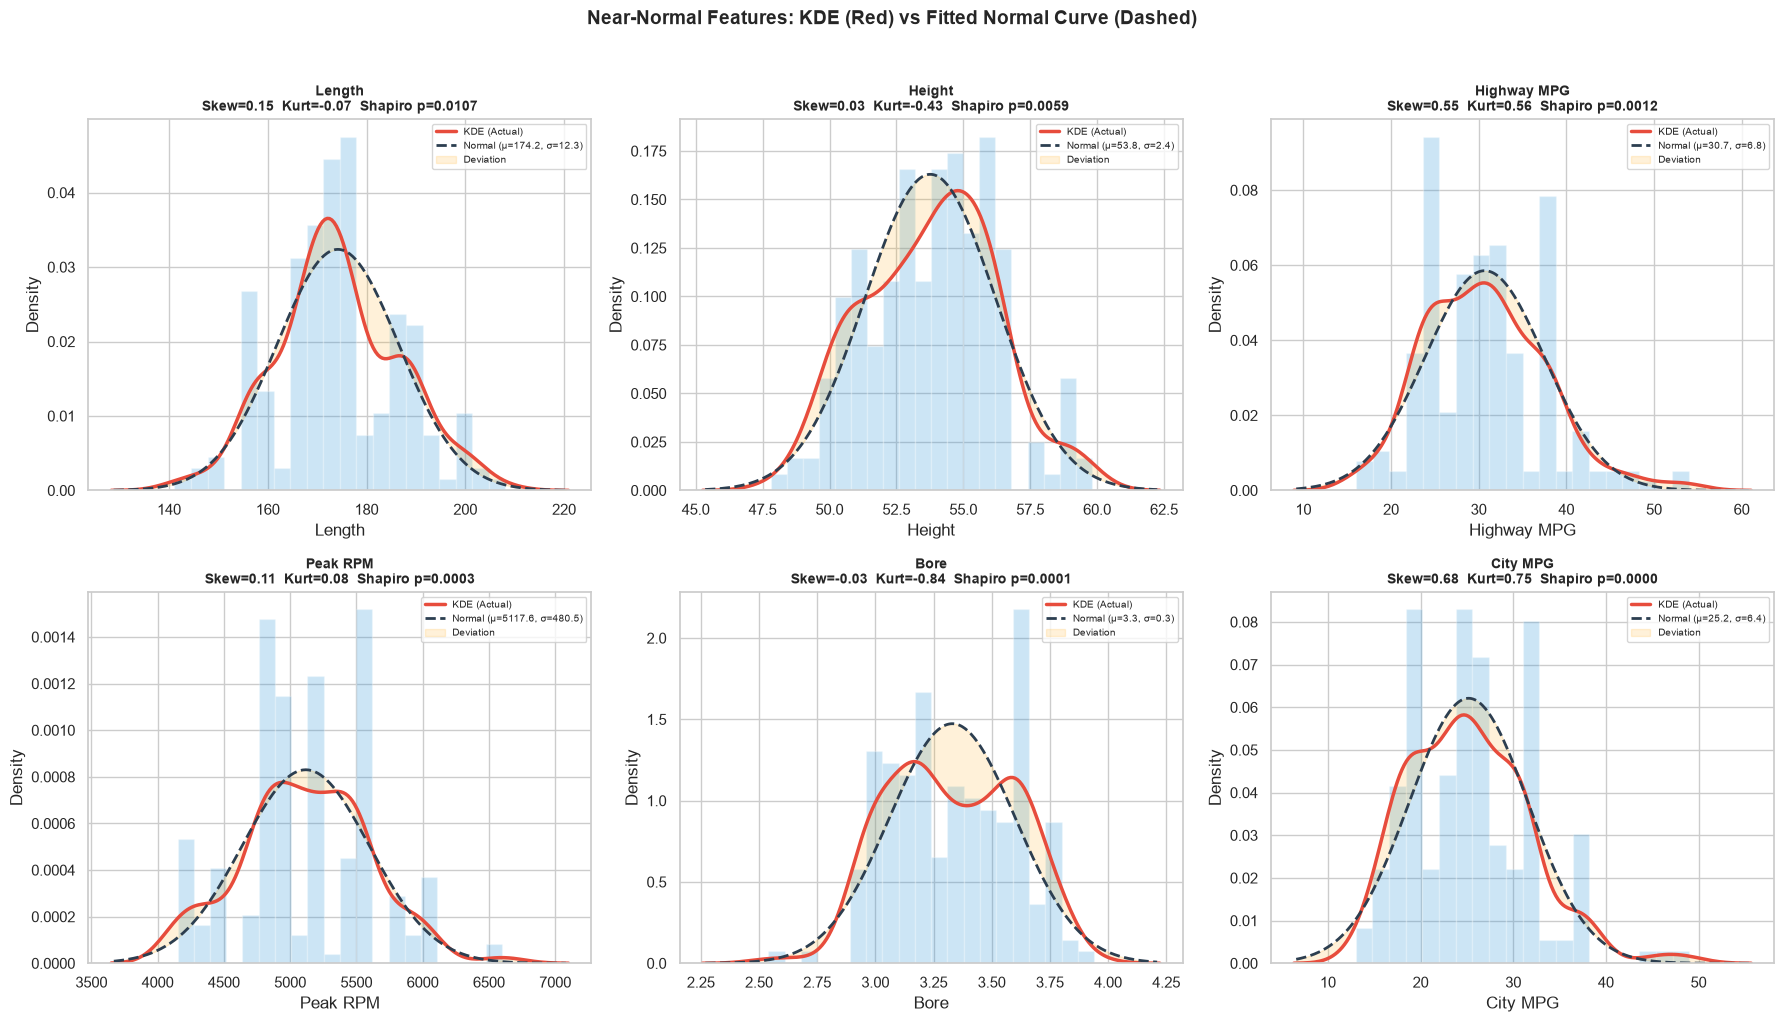

In [77]:
# --- Features closest to Normal ---
# Selected by: lowest |skewness| and highest Shapiro-Wilk p-values
normal_cols = ['Length', 'Height', 'Highway MPG', 'Peak RPM', 'Bore', 'City MPG']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(normal_cols):
    kde_vs_normal(df[col], col, axes[i])

plt.suptitle('Near-Normal Features: KDE (Red) vs Fitted Normal Curve (Dashed)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

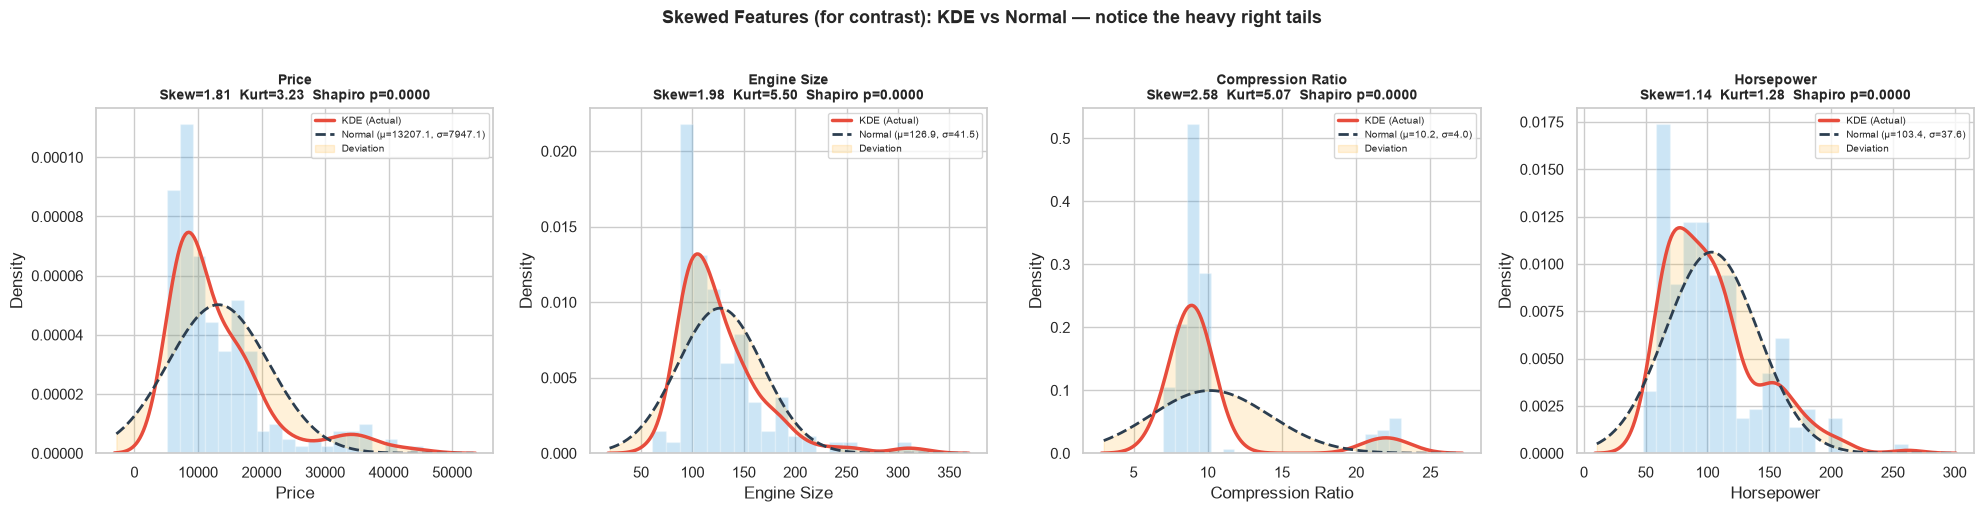

In [78]:
# --- For contrast: features that are clearly NOT normal ---
skewed_cols = ['Price', 'Engine Size', 'Compression Ratio', 'Horsepower']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(skewed_cols):
    kde_vs_normal(df[col], col, axes[i])

plt.suptitle('Skewed Features (for contrast): KDE vs Normal — notice the heavy right tails',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [79]:
# --- Summary table: Normality scorecard ---
all_num = ['Length', 'Height', 'Highway MPG', 'Peak RPM', 'Bore', 'City MPG',
           'Curb Weight', 'Stroke', 'Width', 'Wheelbase',
           'Insurance Risk Score', 'Horsepower', 'Engine Size', 'Price', 'Compression Ratio']

records = []
for col in all_num:
    clean = df[col].dropna()
    stat_val, p = stats.shapiro(clean[:min(len(clean), 150)])
    records.append({
        'Feature': col,
        'Mean': f'{clean.mean():.1f}',
        'Std': f'{clean.std():.1f}',
        'Skewness': f'{clean.skew():.3f}',
        'Kurtosis': f'{clean.kurtosis():.3f}',
        'Shapiro p': f'{p:.5f}',
        'Normal?': '\u2705 Yes' if p > 0.05 else ('\u26a0\ufe0f Borderline' if p > 0.01 else '\u274c No')
    })

norm_df = pd.DataFrame(records).set_index('Feature')
print('Normality Scorecard (sorted by Shapiro p-value):')
norm_df.sort_values('Shapiro p', ascending=False)

Normality Scorecard (sorted by Shapiro p-value):


,Mean,Std,Skewness,Kurtosis,Shapiro p,Normal?
Feature,,,,,,
Length,174.2,12.3,0.154,-0.065,0.01070,⚠️ Borderline
Height,53.8,2.4,0.029,-0.433,0.00591,❌ No
Highway MPG,30.7,6.8,0.550,0.561,0.00119,❌ No
Insurance Risk Score,122.0,35.4,0.766,0.525,0.00088,❌ No
Peak RPM,5117.6,480.5,0.108,0.077,0.00030,❌ No
Bore,3.3,0.3,-0.033,-0.843,0.00012,❌ No
Stroke,3.3,0.3,-0.694,2.029,0.00003,❌ No
City MPG,25.2,6.4,0.680,0.754,0.00001,❌ No
Curb Weight,2555.7,517.3,0.706,0.035,0.00001,❌ No


In [80]:
# --- Final verification ---
print('='*50)
print('✅ CLEANING & ENCODING COMPLETE')
print('='*50)
print(f'\nRows: {df_encoded.shape[0]}  |  Columns: {df_encoded.shape[1]}')
print(f'Missing values: {df_encoded.isnull().sum().sum()}')
print(f'All numeric: {df_encoded.select_dtypes("number").shape[1] == df_encoded.shape[1]}')
print(f'\n--- Cleaned df (before one-hot) ready as: df ---')
print(f'--- Fully encoded df ready as: df_encoded ---')
print(f'\nPreview:')
df_encoded.head()

✅ CLEANING & ENCODING COMPLETE

Rows: 201  |  Columns: 40
Missing values: 51
All numeric: False

--- Cleaned df (before one-hot) ready as: df ---
--- Fully encoded df ready as: df_encoded ---

Preview:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,engine-location,wheel-base,length,width,...,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,NaN,alfa-romero,1,0,2.0,0,88.6,168.8,64.1,...,0,0,0,0,0,0,0,1,0,0
1,3,NaN,alfa-romero,1,0,2.0,0,88.6,168.8,64.1,...,0,0,0,0,0,0,0,1,0,0
2,1,NaN,alfa-romero,1,0,2.0,0,94.5,171.2,65.5,...,0,1,0,0,0,0,0,1,0,0
3,2,164.0,audi,1,0,4.0,0,99.8,176.6,66.2,...,0,0,0,0,0,0,0,1,0,0
4,2,164.0,audi,1,0,4.0,0,99.4,176.6,66.4,...,0,0,0,0,0,0,0,1,0,0
